# A historical heat and rainfall baseline from ERA5

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RiskThinking/crc-docs/blob/main/notebooks/era5_historical_baseline.ipynb) · [GitHub preview](https://github.com/RiskThinking/crc-docs/blob/main/notebooks/era5_historical_baseline.ipynb)

**crc-sdk** turns ERA5 hourly reanalysis into the same canonical H3 hazard curves as every other source, so an open historical baseline can be evaluated at assets exactly like a JRC flood map. This notebook builds two baselines for western and central Europe, 1991-2020 (the WMO climate-normal period):

- **TXx**, the hottest day of each year (annual maximum of daily maximum 2 m temperature), and
- **Rx1day**, the wettest day of each year (annual maximum one-day precipitation).

1. **Plan** -- a lazy, cacheable ERA5 plan: area, years, store; nothing is read until it is needed.
2. **Hazard** -- reduce 30 years of hourly data to 30 *annual extremes per grid cell*, fit GEV with L-moments per cell for both hazards. The fits use the original annual extremes without interpolation or resampling.
3. **Assets** -- read return levels (1-in-2, 1-in-10, 1-in-25 years) for six cities with the portfolio evaluator.
4. **Look closer** -- the 30 annual values behind one city's fitted curve, and a map of the 10-year level.

The first run reads about 33,000 hourly-data chunks per variable from a public bucket (roughly ten minutes per variable on a laptop) and reduces them to annual extremes under `data/era5-source-cache`. Every later run -- this notebook, a different city list, an offline flight -- reuses that cache and finishes in seconds, because it holds annual extremes, never hourly data.

**Workflow:** [Setup and tested versions](https://github.com/RiskThinking/crc-docs/blob/main/ai-playbooks/docs/setup.md) · [All problems](https://github.com/RiskThinking/crc-docs/blob/main/README.md#choose-a-problem)

## Run the notebook

In Colab, choose **Runtime → Run all**. The setup cell installs the required
packages and downloads any small repository files used by the analysis.

In [1]:
#@title Install dependencies and prepare this notebook
import hashlib
import importlib
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys
import sysconfig
import urllib.request

if sys.version_info < (3, 12):
    raise RuntimeError("Use a Python 3.12+ runtime (Colab: Runtime > Change runtime type).")

# Install into this kernel's Python, not a separate shell environment.
REQUIREMENTS = ['crc-sdk[geometry,netcdf,zarr]>=0.8.0a2', 'crc-framework>=0.3.0,<1', 'duckdb>=1.4.5,<2', 'numpy>=1.26,<3', 'pandas>=2.2,<4', 'plotly==6.9.0', 'nbformat>=5.10,<6']
loaded_versions = {
    module: getattr(sys.modules[module], "__version__", None)
    for module in ("numpy", "pandas", "pyarrow", "plotly", "duckdb", "crc_sdk", "crc_framework")
    if module in sys.modules
}
if importlib.util.find_spec("pip") is None:
    subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"])
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--disable-pip-version-check",
    *REQUIREMENTS,
])
importlib.invalidate_caches()
for module, loaded in loaded_versions.items():
    installed = importlib.metadata.version(module.replace("_", "-"))
    if loaded is not None and loaded != installed:
        raise RuntimeError("Packages changed after import. Restart the kernel/session, then run all cells again.")
os.environ["PATH"] = sysconfig.get_path("scripts") + os.pathsep + os.environ.get("PATH", "")
IN_COLAB = importlib.util.find_spec("google.colab") is not None if importlib.util.find_spec("google") else False

# A local checkout keeps its files; standalone/Colab runs download only required resources.
RESOURCE_REVISION = '52ff7a93028cc1e64f3b1df856851650df825dc8'
RESOURCE_SHA256 = {}
REPO_ROOT = next((
    folder for folder in (Path.cwd(), *Path.cwd().parents)
    if (folder / "pyproject.toml").is_file()
    and 'name = "crc-docs"' in (folder / "pyproject.toml").read_text()
), None)
if REPO_ROOT is None:
    REPO_ROOT = next((
        folder for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / ".crc-notebook-revision").is_file()
        and (folder / ".crc-notebook-revision").read_text() == RESOURCE_REVISION
    ), Path.cwd() / ".crc-docs" / RESOURCE_REVISION)
    REPO_ROOT.mkdir(parents=True, exist_ok=True)
    (REPO_ROOT / ".crc-notebook-revision").write_text(RESOURCE_REVISION)
    for relative, expected_hash in RESOURCE_SHA256.items():
        target = REPO_ROOT / relative
        if not target.exists() or hashlib.sha256(target.read_bytes()).hexdigest() != expected_hash:
            url = f"https://raw.githubusercontent.com/RiskThinking/crc-docs/{RESOURCE_REVISION}/{relative}"
            with urllib.request.urlopen(url, timeout=120) as response:
                content = response.read()
            if hashlib.sha256(content).hexdigest() != expected_hash:
                raise RuntimeError(f"Resource checksum mismatch: {relative}")
            target.parent.mkdir(parents=True, exist_ok=True)
            target.write_bytes(content)
NOTEBOOK_DIR = REPO_ROOT / "notebooks"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(NOTEBOOK_DIR)

print(f"Ready: Python {sys.version.split()[0]}, crc-sdk {importlib.metadata.version('crc-sdk')}, "
      f"crc-framework {importlib.metadata.version('crc-framework')}")
print(f"Working directory: {NOTEBOOK_DIR}")


Ready: Python 3.12.10, crc-sdk 0.8.0a2, crc-framework 0.3.0
Working directory: /Users/woozyking/rtai/crc-docs/notebooks


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display
from plotly.subplots import make_subplots
from shapely.geometry import mapping

from crc_sdk.connectors import read_hazard_dataset
from crc_sdk.connectors.blocks import plotting_position_curve
from crc_sdk.geometry import cell_polygon
from crc_sdk.workflows import (
    BlockExtremaPolicy,
    HazardDataset,
    curve_quantiles_at,
    return_periods_to_probabilities,
)

# Use the native interactive renderer; maintainers can opt into saved PNG previews.
STATIC_PREVIEW = os.environ.get("CRC_NOTEBOOK_STATIC_PREVIEW") == "1"
pio.renderers.default = (
    "colab" if IN_COLAB else "plotly_mimetype+png" if STATIC_PREVIEW else "plotly_mimetype"
)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
SOURCE_CACHE = DATA_DIR / "era5-source-cache"

# Western and central Europe. ERA5 itself is global; this box just keeps the
# cache small enough to ship with the notebook.
BOUNDS = (-10.0, 36.0, 22.0, 56.0)
YEARS = (1991, 2020)
# "wb2-1p5" is the 1.5-degree copy of ERA5 from WeatherBench2: about 30 seconds
# per variable-year to read from scratch. "arco-0p25" is the native 0.25-degree
# grid (28 km) from Google's ARCO-ERA5, but stores one hour per chunk, so a
# variable-year takes minutes -- the same call, with a patient first run.
STORE = "wb2-1p5"
RETURN_PERIODS = [2, 10, 25]
# All recipes default to GEV/L-moments. To compare Gumbel for Rx1day,
# set FIT_OVERRIDES = {"rx1day": {"family": "gumbel_r"}} (still L-moments).
# Optional rainfall checks and audited fallback (not enabled by default):
# FIT_OVERRIDES = {"rx1day": {"minimum_return_value": 0,
#     "fallback_family": "gumbel_r", "diagnostics": "rx1day-fits.parquet"}}
FIT_OVERRIDES = {}
CITIES = {
    "London": (-0.13, 51.51),
    "Paris": (2.35, 48.86),
    "Madrid": (-3.70, 40.42),
    "Berlin": (13.40, 52.52),
    "Rome": (12.50, 41.90),
    "Warsaw": (21.01, 52.23),
}

## 1. Plan: one recipe, one area, one record

`HazardDataset.era5(recipe)` is the same immutable, lazy builder as the JRC and EDO workflows. Supported recipes are `txx`, `tnn`, `rx1day` and `rx5day`; each fixes its own definition (daily boundary is UTC, precipitation accumulations are assigned to the day they end in), unit, severe tail and default fitting policy. TXx, TNn, Rx1day and Rx5day all use GEV with L-moments. `FIT_OVERRIDES` above lets you change the family or estimator for each recipe independently; a family-only override retains that recipe's estimator. `explain()` shows what would happen without touching the network.

In [3]:
def era5_plan(recipe):
    fit_options = {
        "diagnostics": DATA_DIR / f"era5_{recipe}_fit_diagnostics.parquet",
        **FIT_OVERRIDES.get(recipe, {}),
    }
    return (
        HazardDataset.era5(recipe, store=STORE)
        .for_area(BOUNDS, land_only=True)
        .years(*YEARS)
        .cache(SOURCE_CACHE, mode="reuse")
        .canonicalize(policy=BlockExtremaPolicy.curated(
            h3_resolution=4, **fit_options
        ))
    )


txx_plan = era5_plan("txx")
rx1day_plan = era5_plan("rx1day")
print(txx_plan.explain())
print(rx1day_plan.explain())

Recipe: txx (annual maximum of daily maximum 2 m temperature (UTC days), degC)
Store: wb2-1p5 (WeatherBench2 ERA5, conservatively regridded to 1.5 degrees, hourly)
Area: -10.0,36.0,22.0,56.0 (land cells only)
Years: 1991-2020 (30); 30 cached, 0 to fetch
Cache: reuse (data/era5-source-cache)
Tail: upper; daily boundary: UTC
Fit: genextreme, sample_lmoments
Network access and fitting occur only at prefetch/materialize/write.
Recipe: rx1day (annual maximum one-day precipitation total (UTC days), mm/day)
Store: wb2-1p5 (WeatherBench2 ERA5, conservatively regridded to 1.5 degrees, hourly)
Area: -10.0,36.0,22.0,56.0 (land cells only)
Years: 1991-2020 (30); 30 cached, 0 to fetch
Cache: reuse (data/era5-source-cache)
Tail: upper; daily boundary: UTC
Fit: genextreme, sample_lmoments
Network access and fitting occur only at prefetch/materialize/write.


## 2. Hazard: annual extremes, fitted per grid cell

`materialize()` opens the cached annual extremes (30 small files per recipe), fits every eligible land cell using its recipe policy. Both hazards fit GEV by unbiased sample L-moments directly to the annual extremes; neither creates additional observations. Fits must contain the observations within their support and produce finite return levels at 2, 5, 10, 20, 50 and 100 years. Each cell needs at least 20 complete years. Constant or invalid records are skipped. Gumbel fallback is opt-in via `FIT_OVERRIDES` and requires a diagnostics sidecar; the fallback must pass the same checks. Optional `minimum_return_value=0` rejects negative rainfall return levels at the validation periods. For checks at other periods, set `validation_return_periods` explicitly; these checks do not bound all possible future evaluations. The summary below distinguishes source grid cells from the H3-expanded canonical rows and shows fitted/skipped counts by reason. Per-cell diagnostics are saved under `data/era5_*_fit_diagnostics.parquet` unless overridden. The canonical file records where the data came from: licence and attribution, retrieval time, the fitted window, that this is a single reanalysis (`single_member`), and that probabilities are annual-exceedance.

In [4]:
txx = txx_plan.materialize(DATA_DIR / "era5_txx_europe.parquet")
rx1day = rx1day_plan.materialize(DATA_DIR / "era5_rx1day_europe.parquet")

for name, dataset in (("TXx", txx), ("Rx1day", rx1day)):
    result = dataset.materialization
    print(f"{name}: {result.canonical_rows:,} canonical rows, "
          f"{result.source_cache_hits} cached years read, {result.source_cache_misses} fetched")


def describe_fit(dataset):
    metadata = dataset.metadata()
    return {
        "source": metadata.source.uri,
        "release": metadata.source.version,
        "licence": metadata.source.licence,
        "window": f"{metadata.temporal_window.start_year}-{metadata.temporal_window.end_year}",
        "ensemble": f"{metadata.ensemble.pooling} ({', '.join(metadata.ensemble.models)})",
        "probabilities": metadata.probability_semantics,
        "fit": f"{', '.join(metadata.fitting.families)}, {metadata.fitting.method}",
        "return periods supported": tuple(round(v, 2) for v in metadata.return_period_support),
    }


display(pd.DataFrame({"TXx": describe_fit(txx), "Rx1day": describe_fit(rx1day)}))

# One diagnostics row per source grid cell, before expansion into H3 cells.
fit_records = []
for recipe, plan in (("txx", txx_plan), ("rx1day", rx1day_plan)):
    if plan.policy.diagnostics is not None:
        records = pq.read_table(plan.policy.diagnostics).to_pandas()
        records["recipe"] = recipe
        fit_records.append(records)
if fit_records:
    fit_summary = pd.concat(fit_records, ignore_index=True)
    failed = fit_summary["reason"].eq("fit_failed")
    fit_summary.loc[failed, "reason"] = fit_summary.loc[failed, "message"]
    display(
        fit_summary.fillna({"reason": "—", "curve_type": "—"})
        .groupby(["recipe", "outcome", "curve_type", "reason"], dropna=False)
        .size().rename("source grid cells").to_frame()
    )

TXx: 3,488 canonical rows, 30 cached years read, 0 fetched
Rx1day: 3,670 canonical rows, 30 cached years read, 0 fetched


,TXx,Rx1day
source,gs://weatherbench2/datasets/era5/1959-2022-1h-...,gs://weatherbench2/datasets/era5/1959-2022-1h-...
release,final-through-2022-12-31,final-through-2022-12-31
licence,CC-BY-4.0,CC-BY-4.0
window,1991-2020,1991-2020
ensemble,single_member (ERA5),single_member (ERA5)
probabilities,annual_exceedance,annual_exceedance
fit,"genextreme, sample_lmoments","genextreme, sample_lmoments"
return periods supported,"(1.02, 53.79)","(1.02, 53.79)"


source grid cells
recipe outcome curve_type reason                                                    
rx1day fitted  genextreme —                                                      182
       skipped —          no_data                                                140
txx    fitted  genextreme —                                                      173
       skipped —          no_data                                                140
                          observations outside fitted GEV support                  9

## 3. Assets: return levels at six cities

The result is an ordinary canonical `HazardDataset`, so the portfolio evaluator works unchanged: points are matched to H3 cells and each cell's fitted curve is read at the requested return periods. A 1-in-10 TXx is the temperature a typical year's hottest day exceeds with 10% probability.

In [5]:
assets = pa.table({
    "asset_id": list(CITIES),
    "longitude": [lon for lon, _ in CITIES.values()],
    "latitude": [lat for _, lat in CITIES.values()],
})


def evaluate(dataset, name, stem):
    path = DATA_DIR / f"era5_{stem}_cities.parquet"
    dataset.for_assets(assets).return_periods(RETURN_PERIODS).write_parquet(path)
    table = pq.read_table(path).to_pandas().set_index("asset_id")
    return table[[f"value_rp{rp}" for rp in RETURN_PERIODS]].rename(
        columns={f"value_rp{rp}": f"{name} 1-in-{rp}" for rp in RETURN_PERIODS}
    )


levels = evaluate(txx, "TXx (°C)", "txx").join(evaluate(rx1day, "Rx1day (mm)", "rx1day"))
levels.round(1)

,TXx (°C) 1-in-2,TXx (°C) 1-in-10,TXx (°C) 1-in-25,Rx1day (mm) 1-in-2,Rx1day (mm) 1-in-10,Rx1day (mm) 1-in-25
asset_id,,,,,,
London,24.7,27.6,28.9,23.0,27.7,29.5
Rome,30.5,31.7,32.0,39.6,53.2,58.4
Madrid,36.9,38.5,39.0,22.5,29.4,33.1
Paris,33.1,36.9,38.7,21.4,28.0,31.6
Warsaw,32.6,34.9,35.9,22.6,35.9,43.4
Berlin,33.6,36.5,37.5,22.6,36.3,43.2


## 4. Look closer: the 30 values behind a curve

Nothing here is hidden: `annual_extremes()` returns the exact per-year, per-cell values the fit saw. For each city below (using the nearest ERA5 land cell), the dots are its 30 annual TXx values placed at their empirical return periods, and the line is the fitted curve read back through the evaluator. A heat-wave year such as 2003 or 2019 shows up as the top dots.

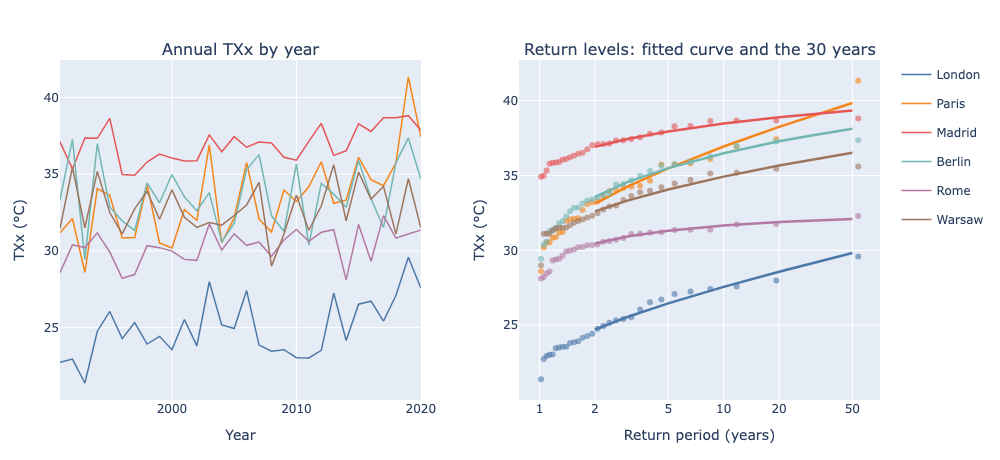

Years most often hottest across the area's cells: {2019: 53, 2007: 25, 2003: 22, 2017: 16}


In [6]:
annual = txx_plan.annual_extremes().to_pandas()
CURVE_RPS = [2, 3, 5, 10, 20, 30, 50]


cells = annual[["latitude", "longitude"]].drop_duplicates().to_numpy()


def nearest_land_cell(lon, lat):
    # ERA5 here is a 1.5-degree grid with sea cells masked out, so a coastal
    # city may sit in a masked cell: use the nearest cell that has a record.
    distance = (cells[:, 0] - lat) ** 2 + ((cells[:, 1] - lon) * np.cos(np.radians(lat))) ** 2
    return tuple(cells[distance.argmin()])


NEAREST = {city: nearest_land_cell(lon, lat) for city, (lon, lat) in CITIES.items()}
curve_assets = pa.table({
    "asset_id": list(NEAREST),
    "longitude": [lon for _, lon in NEAREST.values()],
    "latitude": [lat for lat, _ in NEAREST.values()],
})
txx.for_assets(curve_assets).return_periods(CURVE_RPS).write_parquet(
    DATA_DIR / "era5_txx_city_curves.parquet"
)
curves = pq.read_table(DATA_DIR / "era5_txx_city_curves.parquet").to_pandas().set_index("asset_id")

fig = make_subplots(
    rows=1, cols=2, column_widths=[0.5, 0.5], horizontal_spacing=0.12,
    subplot_titles=("Annual TXx by year", "Return levels: fitted curve and the 30 years"),
)
colors = {"London": "#4C78A8", "Paris": "#F58518", "Madrid": "#E45756",
          "Berlin": "#72B7B2", "Rome": "#B279A2", "Warsaw": "#9D755D"}
for city, (lon, lat) in CITIES.items():
    cell_lat, cell_lon = NEAREST[city]
    series = annual[(annual["latitude"] == cell_lat) & (annual["longitude"] == cell_lon)].sort_values("year")
    fig.add_trace(go.Scatter(x=series["year"], y=series["value"], mode="lines", name=city,
                             line=dict(color=colors[city], width=1.5), legendgroup=city), row=1, col=1)
    periods, values = plotting_position_curve(series["value"].to_numpy(), "upper")
    fig.add_trace(go.Scatter(x=periods, y=values, mode="markers", name=f"{city} (years)",
                             marker=dict(color=colors[city], size=6, opacity=0.6),
                             legendgroup=city, showlegend=False), row=1, col=2)
    fig.add_trace(go.Scatter(x=CURVE_RPS, y=[curves.loc[city, f"value_rp{rp}"] for rp in CURVE_RPS],
                             mode="lines", line=dict(color=colors[city], width=2.5),
                             legendgroup=city, showlegend=False), row=1, col=2)
fig.update_xaxes(title_text="Year", row=1, col=1)
fig.update_xaxes(
    title_text="Return period (years)", type="log",
    tickmode="array", tickvals=[1, 2, 5, 10, 20, 50],
    ticktext=["1", "2", "5", "10", "20", "50"], row=1, col=2,
)
fig.update_yaxes(title_text="TXx (°C)", row=1, col=1)
fig.update_yaxes(title_text="TXx (°C)", row=1, col=2)
fig.update_layout(margin=dict(l=60, r=20, t=60, b=60), width=1000, height=460)
fig.show()

hottest = annual.loc[annual.groupby(["latitude", "longitude"])["value"].idxmax(), "year"].value_counts().head(4)
print("Years most often hottest across the area's cells:", {int(year): int(count) for year, count in hottest.items()})

### The 10-year level on a map

One value per H3 cell: the temperature the year's hottest day reaches or exceeds once in ten years. Curves are read straight from the canonical file, the same path any consumer of canonical hazards uses.

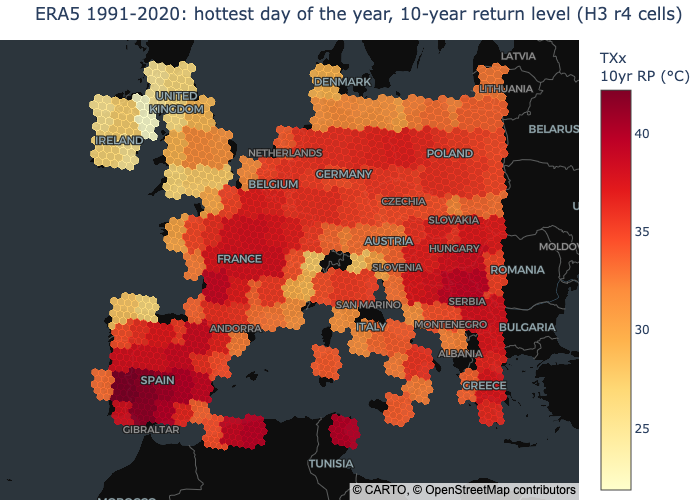

In [7]:
metadata = txx.metadata()
probability = return_periods_to_probabilities([10], tail=metadata.return_period_tail)[0]
canonical = read_hazard_dataset(txx.provider.source)
level_10 = pd.DataFrame({
    "cell": canonical["cell_index"].to_pylist(),
    "txx_10yr": curve_quantiles_at(canonical, probability),
}).groupby("cell", as_index=False).max()

hex_geojson = {
    "type": "FeatureCollection",
    "features": [
        {"type": "Feature", "id": str(cell), "geometry": mapping(cell_polygon(cell))}
        for cell in level_10["cell"]
    ],
}
fig_map = go.Figure(go.Choroplethmap(
    geojson=hex_geojson, locations=level_10["cell"].astype(str), z=level_10["txx_10yr"],
    colorscale="YlOrRd", marker_line_width=0, marker_opacity=0.85,
    colorbar_title="TXx<br>10yr RP (°C)",
))
fig_map.update_layout(
    map_style="carto-darkmatter", map_zoom=3.1,
    map_center={"lat": (BOUNDS[1] + BOUNDS[3]) / 2, "lon": (BOUNDS[0] + BOUNDS[2]) / 2},
    margin=dict(l=0, r=0, t=40, b=0),
    title="ERA5 1991-2020: hottest day of the year, 10-year return level (H3 r4 cells)",
)
fig_map.show()

## How to read this, and its limits

- **Reanalysis is not observation.** ERA5 blends observations with a weather model, and its biases move with the observing system. At 1.5 degrees (this notebook) a grid cell is an area average, so city-scale maxima read cool: Madrid's 1-in-10 TXx here is a regional value, not a station record. The native 0.25-degree store (`store="arco-0p25"`) is sharper but takes minutes per variable-year the first time.
- **Convective rainfall extremes are underestimated** by reanalysis; treat Rx1day as a regional baseline, not a design storm.
- **Definitions are explicit.** Days are UTC; hourly temperature is instantaneous, so the daily maximum is the largest of 24 hourly values. Only final (non-preliminary) ERA5 years are used.
- **Thirty values per cell is a short record.** Return levels beyond about 30 years are extrapolations of the fitted distribution (GEV by default); the file records the supported range (`return_period_support`), and evaluation warns when you leave it.
- **Provenance travels with the file.** The licence (CC-BY-4.0), attribution, retrieval date, fit method and platform are in the Parquet metadata; `diagnostics=` on the policy writes a row for every cell that was fitted or skipped.

## Scaling this up

Change `BOUNDS` and `YEARS`, pick another recipe (`tnn`, `rx5day`), or switch `STORE` -- the plan, cache manifest and canonical output stay the same. `plan.prefetch()` fills the cache ahead of time and `mode="offline"` then guarantees no network access. Validate return levels against station observations before using these regional baselines for local decisions. Changing a fitting policy reuses the annual-extremes cache, but rerun `materialize()` to replace previously fitted canonical files.